# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [2]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [3]:
# Does gender affect survivability? yes
sex_survival = df.groupby('Sex')['Survived'].mean()

print(sex_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


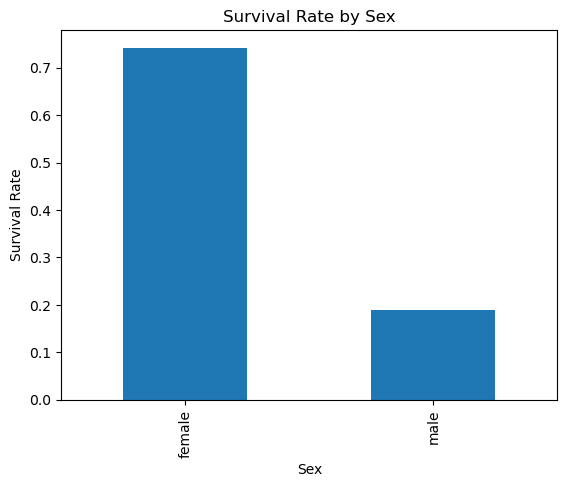

In [ ]:
Females had a much higher survival rate than males. 74% of females survived compared to 19% of males. 
Most likely to survive will be female and least likely will be male.

In [12]:
# Create age groups
df.loc[df['Age'] < 13, 'Age_Group'] = 'Children'
df.loc[(df['Age'] >= 13) & (df['Age'] < 30), 'Age_Group'] = 'Young Adult'
df.loc[(df['Age'] >= 30) & (df['Age'] < 50), 'Age_Group'] = 'Adult'
df.loc[df['Age'] >= 50, 'Age_Group'] = 'Elder'
# Calculate survival rate by age group
age_survival = df.groupby('Age_Group')['Survived'].mean()

print(age_survival)

Age_Group
Adult          0.417969
Children       0.579710
Elder          0.364865
Young Adult    0.368254
Name: Survived, dtype: float64


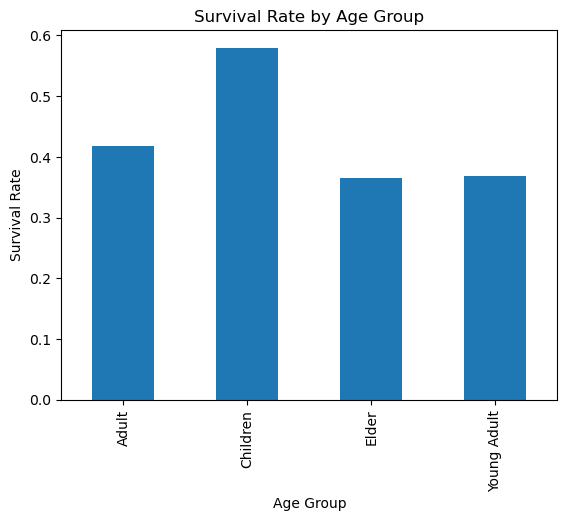

In [13]:
age_survival.plot(kind='bar')

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

In [ ]:
Children had the highest survival rate at 58%. Older adults had the lowest survival rate at 36%. 
Based on age, the most likely to survive profile will be a child, least likely to survive will be older adults.

In [16]:
# Passenger class survival rates
class_survival = df.groupby('Pclass')['Survived'].mean()

# Rename the class numbers, making it easier to read.
class_survival.index = ['1st Class', '2nd Class', '3rd Class']

print(class_survival)

1st Class    0.629630
2nd Class    0.472826
3rd Class    0.242363
Name: Survived, dtype: float64


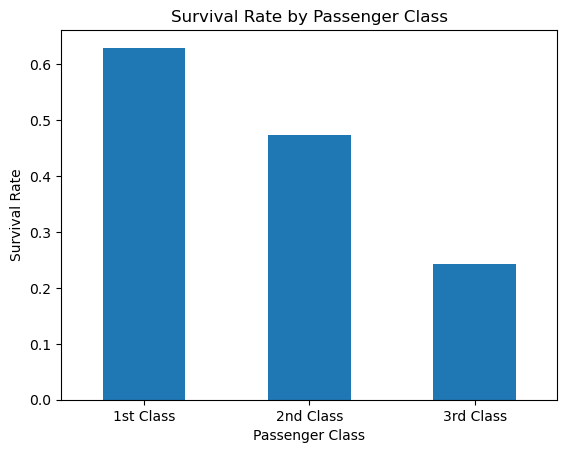

In [19]:
class_survival.plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0) #rotates label for horizontal viewing.
plt.show()

In [20]:
# Create fare groups
df.loc[df['Fare'] < 10, 'Fare_Group'] = 'Low Fare'
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 30), 'Fare_Group'] = 'Medium Fare'
df.loc[df['Fare'] >= 30, 'Fare_Group'] = 'High Fare'

# Calculate survival rate by fare group
fare_survival = df.groupby('Fare_Group')['Survived'].mean()

print(fare_survival)

Fare_Group
High Fare      0.587500
Low Fare       0.199405
Medium Fare    0.425397
Name: Survived, dtype: float64


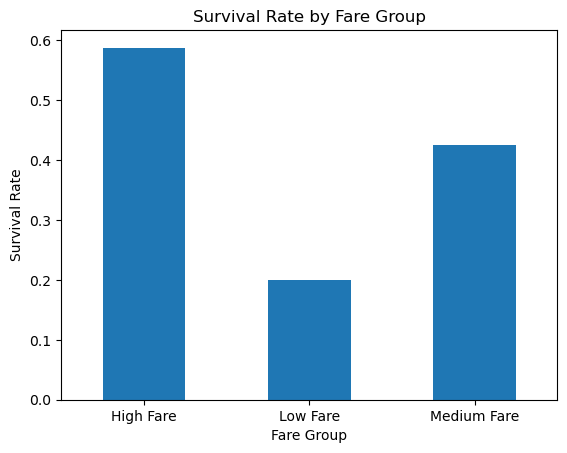

In [21]:
fare_survival.plot(kind='bar')

plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

In [ ]:
High fare passengers had the highest survival rate at 59%. Low fare passengers had the lowest survival rate at 20%. 
Based on fare, the most likely to survive profile will have a high fare and the least likely to survive profile will have a low fare.

In [22]:
# Create a total number of travel companions
df['Travel_Companions'] = df['SibSp'] + df['Parch']

# Calculate survival rate by number of travel companions
companion_survival = df.groupby('Travel_Companions')['Survived'].mean()

print(companion_survival)

Travel_Companions
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


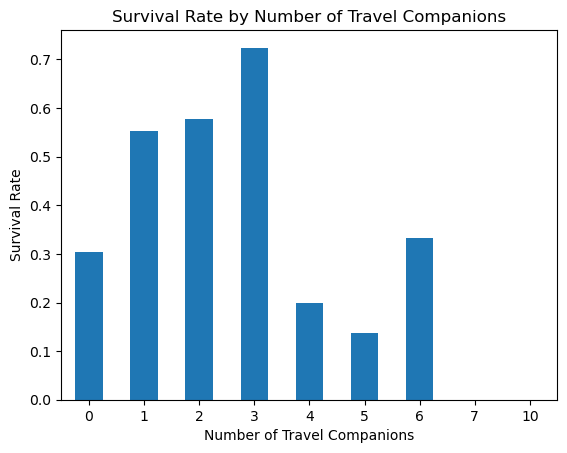

In [23]:
companion_survival.plot(kind='bar')

plt.title('Survival Rate by Number of Travel Companions')
plt.xlabel('Number of Travel Companions')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

In [24]:
# Create a total number of travel companions
df['Travel_Companions'] = df['SibSp'] + df['Parch']

# Survival rate by travel companions
companion_survival = df.groupby('Travel_Companions')['Survived'].mean()

print(companion_survival)

Travel_Companions
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


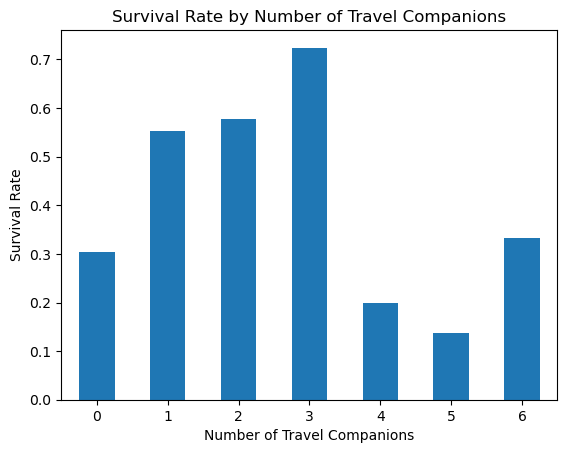

In [27]:
# Remove 0% companion groups from the graph. cleaner
companion_survival_filtered = companion_survival[companion_survival.index <= 6]

companion_survival_filtered.plot(kind='bar')

plt.title('Survival Rate by Number of Travel Companions')
plt.xlabel('Number of Travel Companions')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

In [ ]:
Passengers traveling with 3 companions had the highest survival rate at 72%. 
Passengers traveling with 5 companions had one of the lowest survival rates at 14%. 
I used 5 companions for the least likely to survive profile because the larger groups had very few passengers.

In [28]:
# Survival rate by port of departure
embarked_survival = df.groupby('Embarked')['Survived'].mean()

print(embarked_survival)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


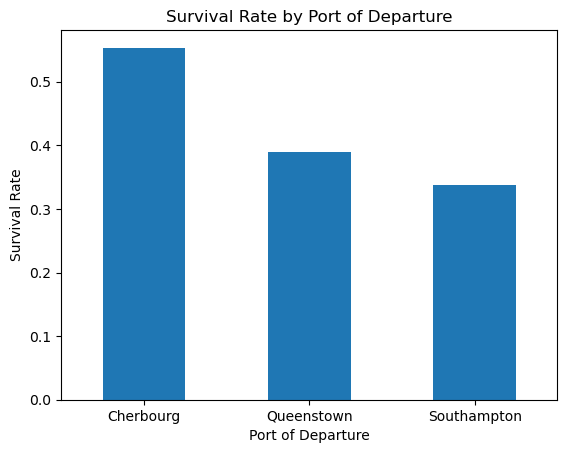

In [34]:
embarked_survival.plot(kind='bar')

# Rename the port names, making it easier to read.
embarked_survival.index = ['Cherbourg', 'Queenstown', 'Southampton']

plt.title('Survival Rate by Port of Departure')
plt.xlabel('Port of Departure')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)

plt.show()

In [ ]:
Passengers who departed from Cherbourg had the highest survival rate at 55%. 
Passengers who departed from Southampton had the lowest survival rate at 34%.

In [40]:
# Passengers who most likely fit the survive profile
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Age_Group'] == 'Children') &
    (df['Pclass'] == 1) &
    (df['Fare_Group'] == 'High Fare') &
    (df['Travel_Companions'] == 3) &
    (df['Embarked'] == 'C')
]

# If no exact match is found, remove the 3-companion requirement
if most_likely.empty:
    most_likely = df[
        (df['Sex'] == 'female') &
        (df['Age_Group'] == 'Children') &
        (df['Pclass'] == 1) &
        (df['Fare_Group'] == 'High Fare') &
        (df['Embarked'] == 'C')
    ]

# If still empty, remove the port requirement too
if most_likely.empty:
    most_likely = df[
        (df['Sex'] == 'female') &
        (df['Age_Group'] == 'Children') &
        (df['Pclass'] == 1) &
        (df['Fare_Group'] == 'High Fare')
    ]

most_likely[
    ['Name', 'Age', 'Sex', 'Pclass', 'Fare',
     'Travel_Companions', 'Embarked', 'Survived']
]

,Name,Age,Sex,Pclass,Fare,Travel_Companions,Embarked,Survived
297,"Allison, Miss. Helen Loraine",2.0,female,1,151.55,3,S,0


In [ ]:
A profile can show who was more likely to survive based on the data, but it does not guarantee what happened to an individual passenger.

In [41]:
# Passengers who most likely fit the least likely to survive profile
least_likely = df[
    (df['Sex'] == 'male') &
    (df['Age_Group'] == 'Elder') &
    (df['Pclass'] == 3) &
    (df['Fare_Group'] == 'Low Fare') &
    (df['Travel_Companions'] == 5) &
    (df['Embarked'] == 'S')
]

# If no exact match is found, remove the 5-companion requirement
if least_likely.empty:
    least_likely = df[
        (df['Sex'] == 'male') &
        (df['Age_Group'] == 'Elder') &
        (df['Pclass'] == 3) &
        (df['Fare_Group'] == 'Low Fare') &
        (df['Embarked'] == 'S')
    ]

# If still empty, remove the port requirement too
if least_likely.empty:
    least_likely = df[
        (df['Sex'] == 'male') &
        (df['Age_Group'] == 'Elder') &
        (df['Pclass'] == 3) &
        (df['Fare_Group'] == 'Low Fare')
    ]

least_likely[
    ['Name', 'Age', 'Sex', 'Pclass', 'Fare',
     'Travel_Companions', 'Embarked', 'Survived']
]

,Name,Age,Sex,Pclass,Fare,Travel_Companions,Embarked,Survived
94,"Coxon, Mr. Daniel",59.0,male,3,7.2500,0,S,0
152,"Meo, Mr. Alfonzo",55.5,male,3,8.0500,0,S,0
222,"Green, Mr. George Henry",51.0,male,3,8.0500,0,S,0
326,"Nysveen, Mr. Johan Hansen",61.0,male,3,6.2375,0,S,0
406,"Widegren, Mr. Carl/Charles Peter",51.0,male,3,7.7500,0,S,0
482,"Rouse, Mr. Richard Henry",50.0,male,3,8.0500,0,S,0
631,"Lundahl, Mr. Johan Svensson",51.0,male,3,7.0542,0,S,0
851,"Svensson, Mr. Johan",74.0,male,3,7.7750,0,S,0


In [42]:
Most likely profile:
    Helen Loraine Allison: An interesting fact about Loraine is that she was the only child in first or second class who died on the Titanic. 
    Even though her data fit many of the “most likely to survive” features, she still did not survive.  

Least likely profile:
    Daniel Coxon: Daniel Coxon was known as “Popcorn Dan” because he worked as a popcorn and peanut vendor in Wisconsin. 
    He traveled third class and did not survive.

SyntaxError: invalid character '“' (U+201C) (3811614367.py, line 3)